In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os
import sys

sys.path.append("..")

# Folders
DATA_DIR = "/media/gabriel/500 BKP/datasets/Investments"
DATABASE_DIR = "/media/gabriel/500 BKP/datasets/Investments/stock_data.db"
DFP_DIR = os.path.join(DATA_DIR, "CVM - DFP")
MAPPING_FILE = "../data/mapping.csv"

### Loading From Database

In [3]:
import pandas as pd
from sqlalchemy import create_engine

engine = create_engine(f"sqlite:///{DATABASE_DIR}")

query_fin = "SELECT * FROM financials"
query_prices = "SELECT * FROM prices WHERE close IS NOT NULL and Volume > 0"

df_financials = pd.read_sql(query_fin, engine)
df_prices = pd.read_sql(query_prices, engine)
df_prices['Date'] = pd.to_datetime(df_prices['Date'])

In [6]:
print(df_financials.shape)
df_financials.head()

(1166, 10)


,CNPJ,TICKER1,TICKER2,TICKER3,NOME,ESCALA_MOEDA,DT_FIM_EXERC,RECEITA_LIQUIDA,LUCRO_CONSOLIDADO,PATRIMONIO_LIQUIDO
0,12.528.708/0001-07,AERI3.SA,None,None,AERIS IND. E COM. DE EQUIP. PARA GER. DE ENG. ...,MIL,2020-12-31,2208702.0,113199.0,966252.0
1,04.128.563/0001-10,TIET11.SA,TIET3.SA,TIET4.SA,AES TIETE ENERGIA SA,MIL,2020-12-31,2011192.0,848021.0,1842458.0
2,21.240.146/0001-84,AGXY3.SA,None,None,AGROGALAXY PARTICIPAÇÕES S.A. - EM RECUPERAÇÃO...,MIL,2020-12-31,2630908.0,76211.0,1020148.0
3,42.771.949/0001-35,AALR3.SA,None,None,ALLIANÇA SAÚDE E PARTICIPAÇÕES S.A.,MIL,2020-12-31,928787.0,-92431.0,1223684.0
4,20.247.322/0001-47,ALLD3.SA,None,None,ALLIED TECNOLOGIA S.A.,MIL,2020-12-31,4722413.0,167645.0,1130587.0


In [7]:
print(df_prices.shape)
df_prices.loc[df_prices['ticker'] == 'WEGE3.SA'].head()

(480847, 8)


,Date,Open,High,Low,Close,Volume,ticker,Adj Close
467155,2015-05-04,5.198874,5.393467,5.198874,5.383738,4570800.0,WEGE3.SA,None
467156,2015-05-05,5.377250,5.451844,5.331844,5.451844,4040660.0,WEGE3.SA,None
467157,2015-05-06,5.448601,5.494007,5.367521,5.393466,3028220.0,WEGE3.SA,None
467158,2015-05-07,5.416170,5.455089,5.386981,5.403197,1884740.0,WEGE3.SA,None
467159,2015-05-08,5.432385,5.481034,5.390223,5.481034,1916720.0,WEGE3.SA,None


### Initial Screening - Number of Records

In [8]:
# Start date, end date and number of records for each ticker
df_dates = df_prices.groupby('ticker').agg(
    {'Date': ['min', 'max', 'count']}
).reset_index()

Text(0.5, 1.0, 'Number of days with prices per Ticker')

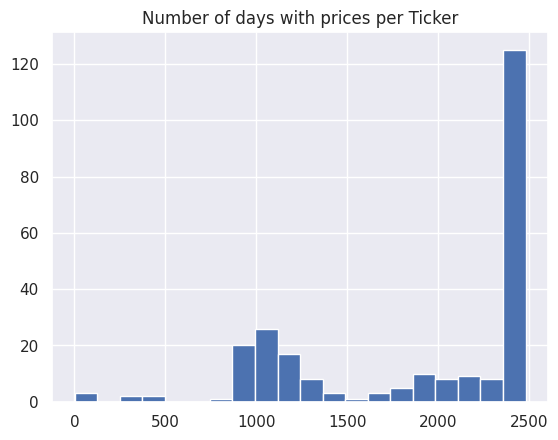

In [13]:
import matplotlib.pyplot as plt
import seaborn as sn

sn.set_theme(style="darkgrid")

plt.hist(df_dates[('Date', 'count')], bins= 20)
plt.title("Number of days with prices per Ticker")

In [26]:
# Selecting tickers with more than 2400 days of prices and active as of 2025-05-02
df_dates_filtered = df_dates.loc[(df_dates[('Date', 'count')] > 2400) & (df_dates[('Date', 'max')] == pd.to_datetime("2025-05-02"))]
filtered_tickers = pd.DataFrame(df_dates_filtered['ticker'].unique(), columns = ['ticker'])
filtered_tickers

,ticker
0,ABEV3.SA
1,AGRO3.SA
2,ALPA4.SA
3,ALUP11.SA
4,AMAR3.SA
...,...
117,VIVT3.SA
118,VLID3.SA
119,WEGE3.SA
120,WIZC3.SA


In [27]:
# Selecting tickers with more than 2400 days of prices and active as of 2025-05-02
df_prices_filtered = df_prices.merge(
    filtered_tickers,
    how='inner',
    on='ticker'
)
df_prices_filtered

,Date,Open,High,Low,Close,Volume,ticker,Adj Close
0,2015-05-04,13.764462,14.089948,13.742762,13.988686,9874100.0,ABEV3.SA,None
1,2015-05-05,13.887427,14.270777,13.836794,14.155048,11569000.0,ABEV3.SA,None
2,2015-05-06,14.285243,14.675828,14.133350,14.350341,19716900.0,ABEV3.SA,None
3,2015-05-07,14.263543,14.306942,14.075484,14.111650,6641700.0,ABEV3.SA,None
4,2015-05-08,14.306940,14.408202,14.118881,14.379270,10733600.0,ABEV3.SA,None
...,...,...,...,...,...,...,...,...
301872,2025-04-25,14.240744,14.240744,13.414358,13.606541,4671300.0,YDUQ3.SA,None
301873,2025-04-28,13.673805,14.029344,13.654587,14.029344,5200100.0,YDUQ3.SA,None
301874,2025-04-29,14.170000,14.370000,13.870000,14.300000,4742200.0,YDUQ3.SA,None
301875,2025-04-30,14.250000,14.710000,14.030000,14.290000,5422100.0,YDUQ3.SA,None


### Dynamic Time Warping to Find Similar Series

In [123]:
# Pivot to get tickers as columns, dates as rows
pivot_df = df_prices_filtered.pivot(index='Date', columns='ticker', values='Close')

# Optionally fill missing values (interpolation or forward fill)
pivot_df = pivot_df.interpolate(method='time').ffill().bfill()

# Restrict analysis to last 2 years
pivot_df = pivot_df.loc[pivot_df.index >= '2023-01-01']

In [191]:
import numpy as np

# Normalizing the data
pivot_norm = pivot_df / np.array(pivot_df)[0]
pivot_norm2 = (pivot_df - pivot_df.mean()) / pivot_df.std()

In [192]:
from dtaidistance import dtw

# Calculate the distance matrix using DTW
dtw_matrix = dtw.distance_matrix_fast(np.array(pivot_norm.T))
dtw_matrix2 = dtw.distance_matrix_fast(np.array(pivot_norm2.T))

In [193]:
dtw_matrix.shape

(122, 122)

<Axes: >

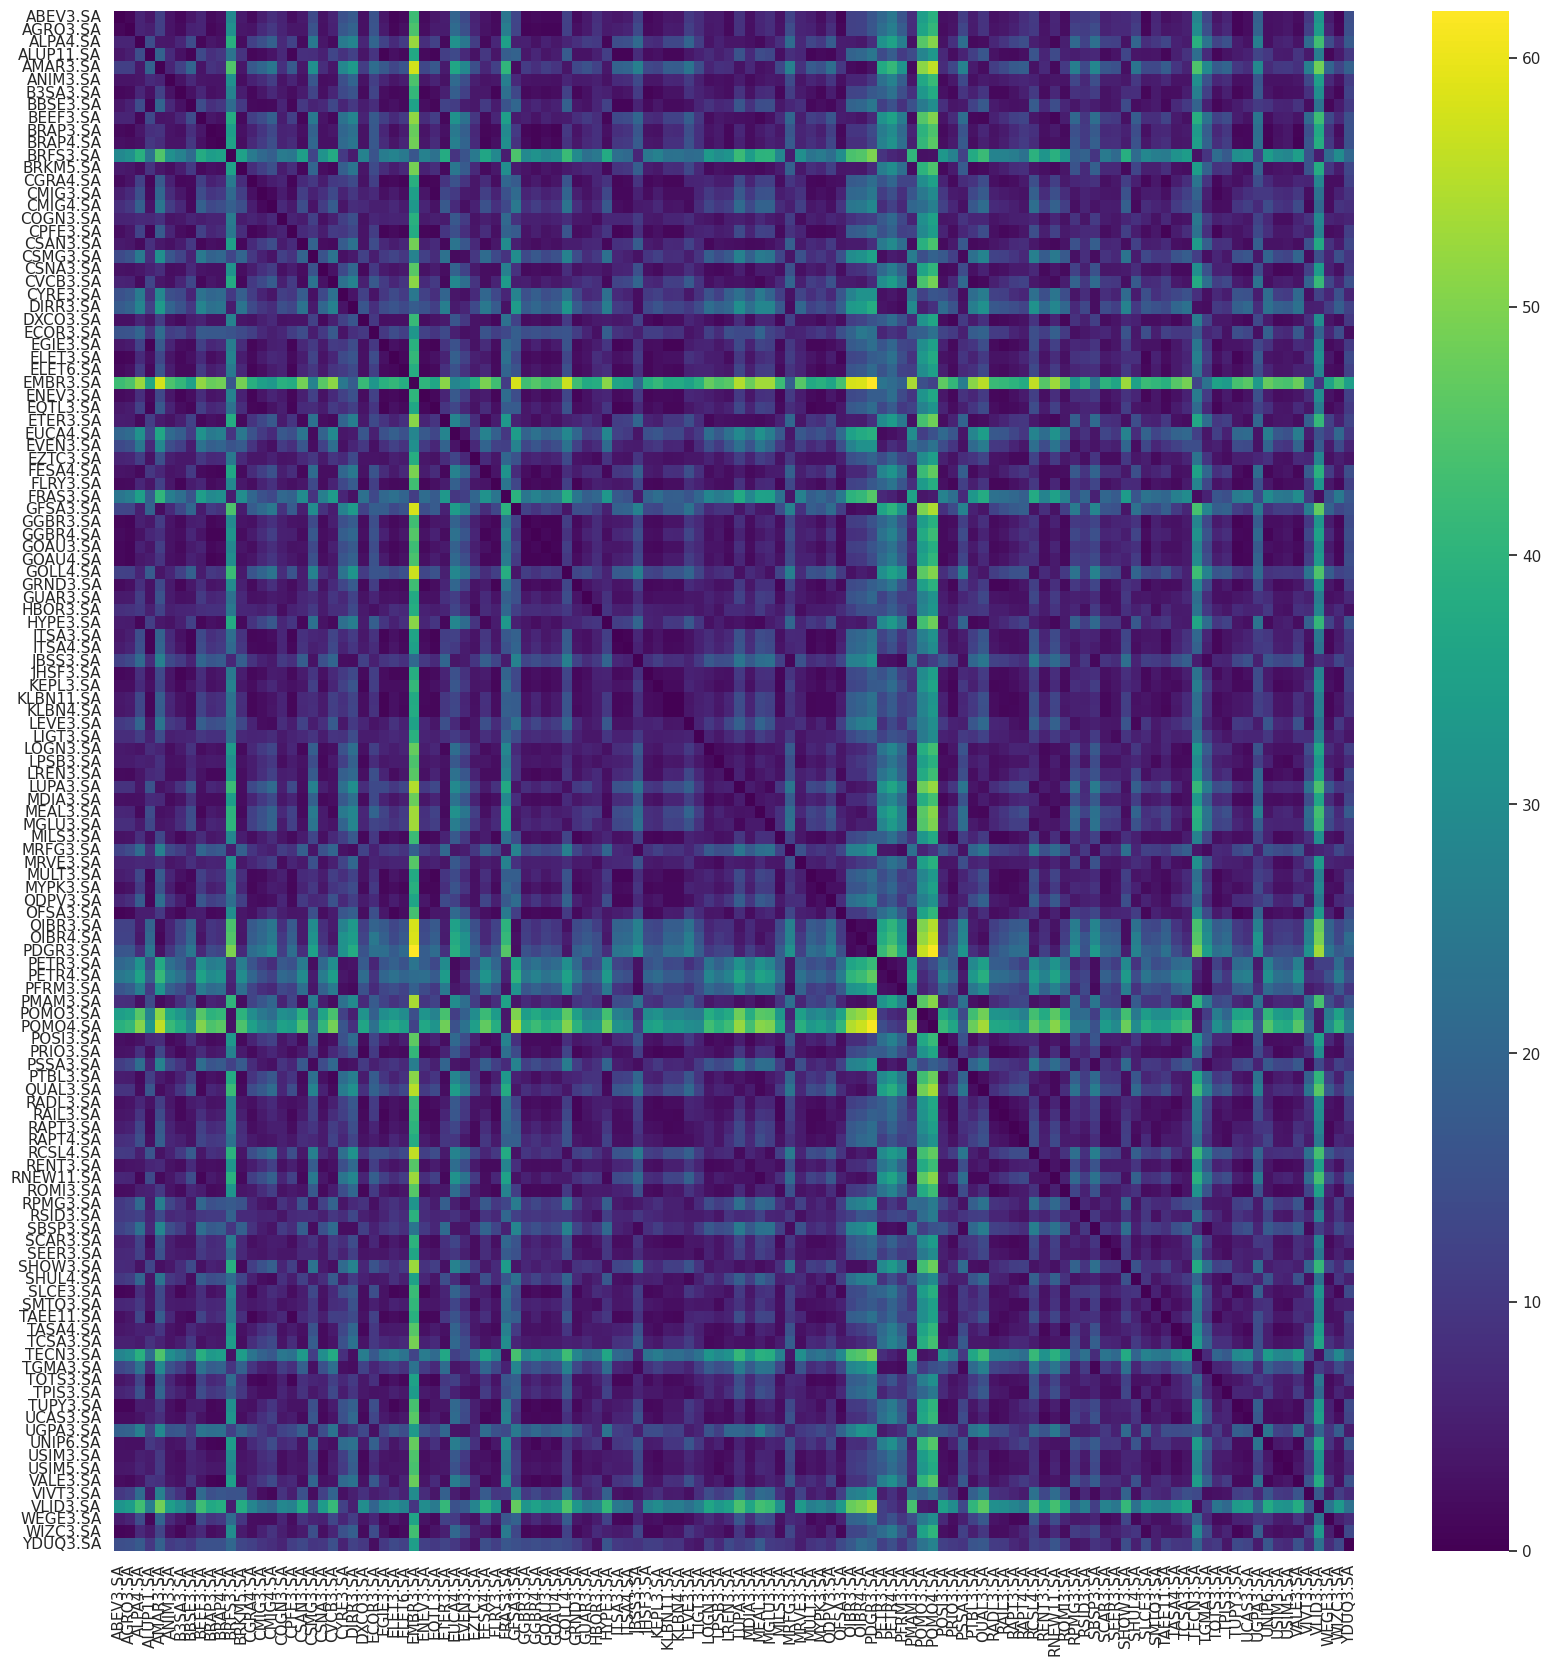

In [194]:
# Plot Heatmap
fig, ax = plt.subplots(figsize=(20, 20))
sn.heatmap(dtw_matrix, cmap='viridis', cbar=True, xticklabels=pivot_df.columns, yticklabels=pivot_df.columns, ax = ax)

/tmp/ipykernel_28840/452807244.py:4: ClusterWarning: The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix
  linked = linkage(dtw_matrix, method='average')


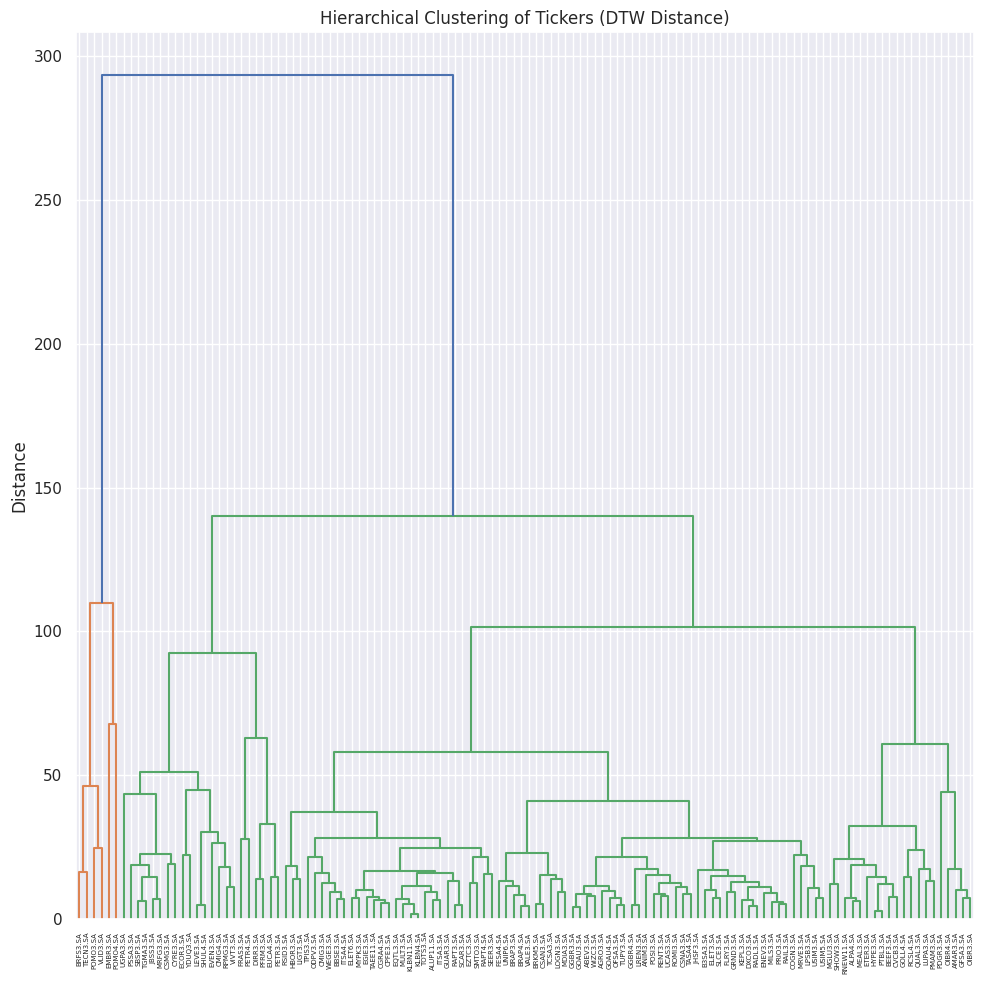

In [195]:
# Clustering Time Series
from scipy.cluster.hierarchy import linkage, dendrogram

linked = linkage(dtw_matrix, method='average')

plt.figure(figsize=(10, 10))
dendrogram(linked, labels=pivot_df.columns.to_list(), orientation='top')
plt.title("Hierarchical Clustering of Tickers (DTW Distance)")
plt.ylabel("Distance")
plt.tight_layout()
plt.show()

/tmp/ipykernel_28840/1077644110.py:5: ClusterWarning: The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix
  linked = linkage(dtw_matrix, method='average')


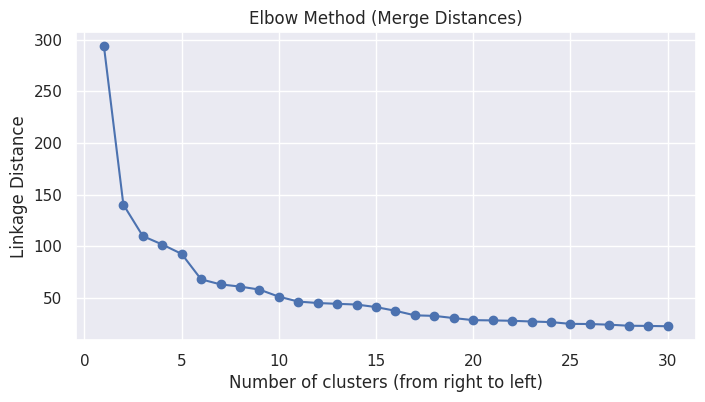

In [196]:
from scipy.cluster.hierarchy import linkage
import matplotlib.pyplot as plt

# Compute linkage as before
linked = linkage(dtw_matrix, method='average')

# Plot the distances between clusters
last_dists = linked[-30:, 2]  # Last 20 merge distances
plt.figure(figsize=(8, 4))
plt.plot(range(1, 31), last_dists[::-1], marker='o')
plt.title("Elbow Method (Merge Distances)")
plt.xlabel("Number of clusters (from right to left)")
plt.ylabel("Linkage Distance")
plt.grid(True)
plt.show()

In [213]:
from scipy.cluster.hierarchy import fcluster

# Compute linkage as before
linked = linkage(dtw_matrix, method='average')
linked2 = linkage(dtw_matrix2, method='average')

# Choose the number of clusters you want
k = 10

# Get cluster assignments
cluster_labels = fcluster(linked, k, criterion='maxclust')
cluster_labels2 = fcluster(linked2, k, criterion='maxclust')

# Map tickers to their cluster
cluster_map = dict(zip(pivot_df.columns.to_list(), cluster_labels))
cluster_map2 = dict(zip(pivot_df.columns.to_list(), cluster_labels2))

/tmp/ipykernel_28840/379472682.py:4: ClusterWarning: The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix
  linked = linkage(dtw_matrix, method='average')
/tmp/ipykernel_28840/379472682.py:5: ClusterWarning: The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix
  linked2 = linkage(dtw_matrix2, method='average')


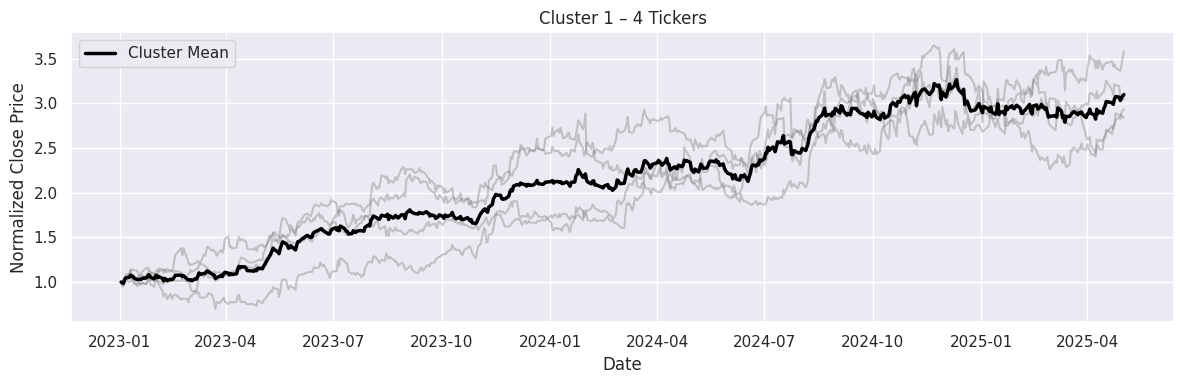

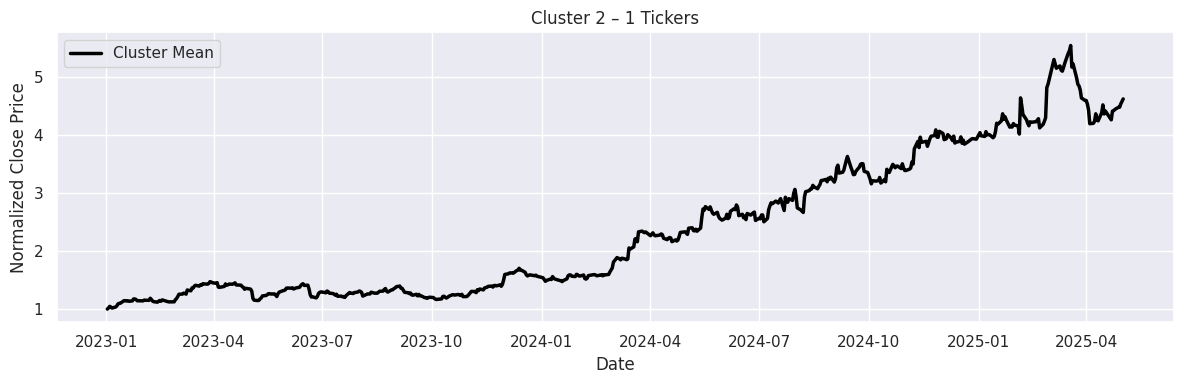

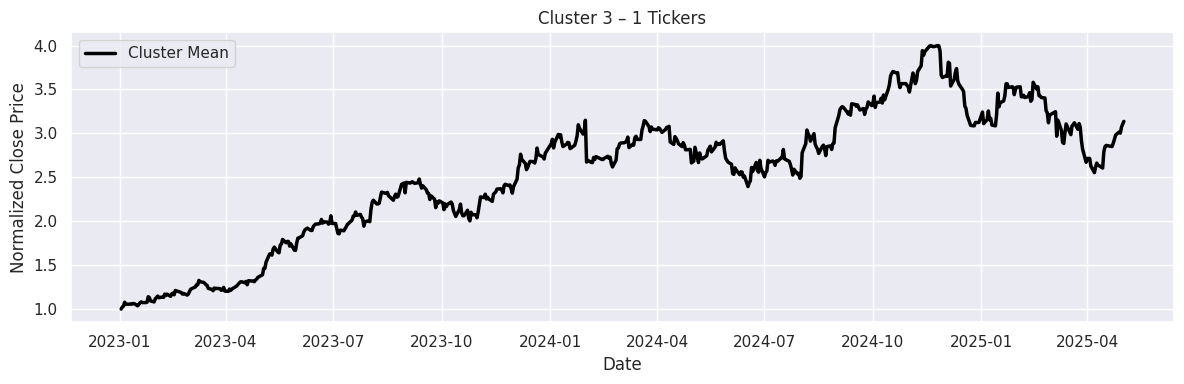

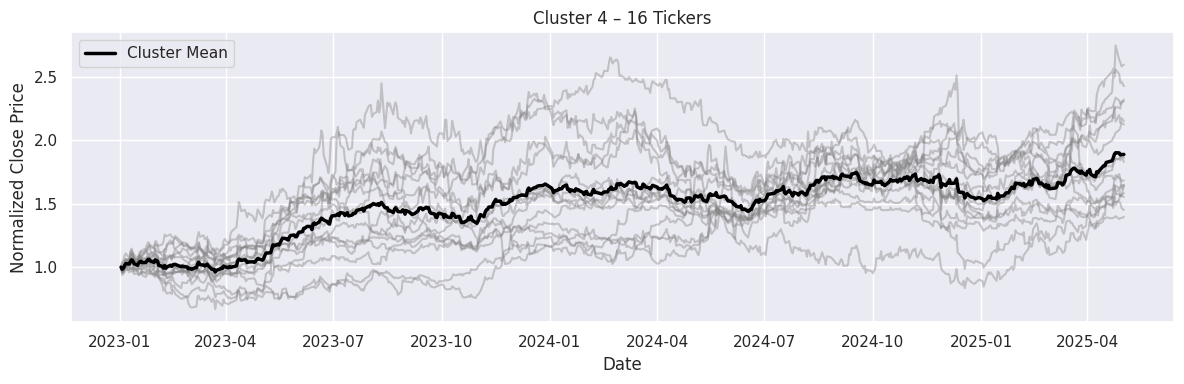

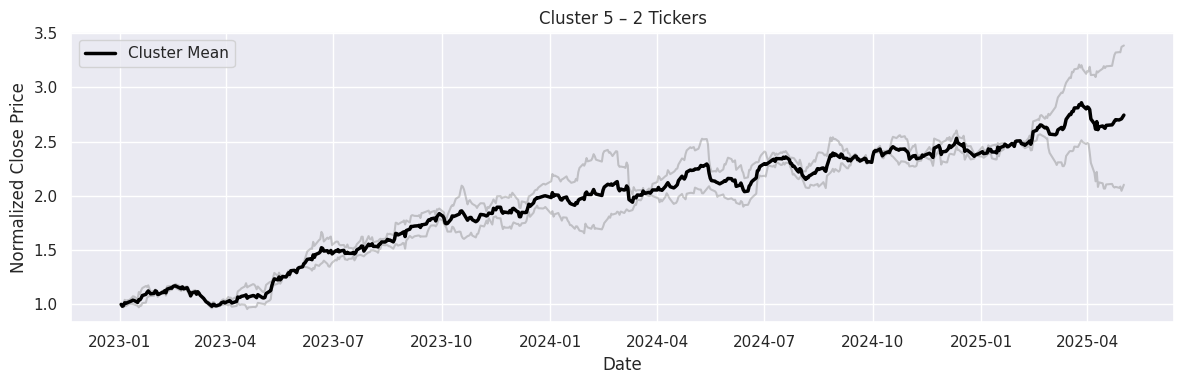

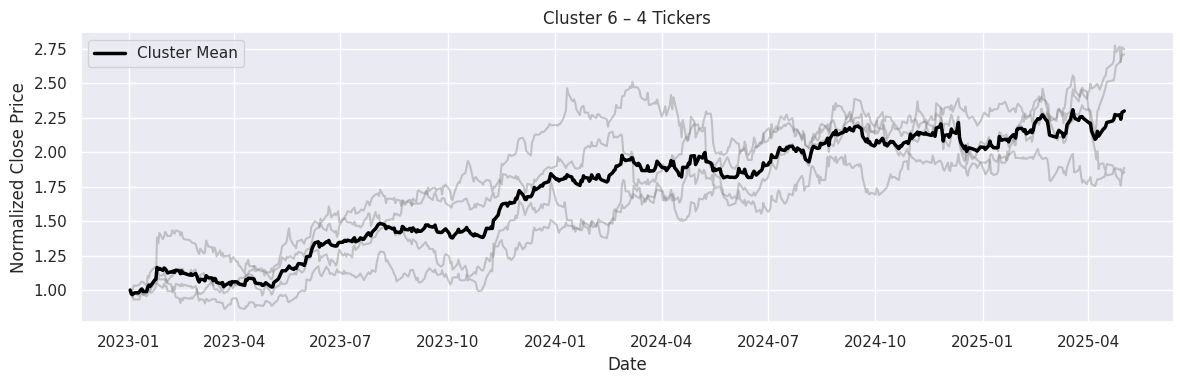

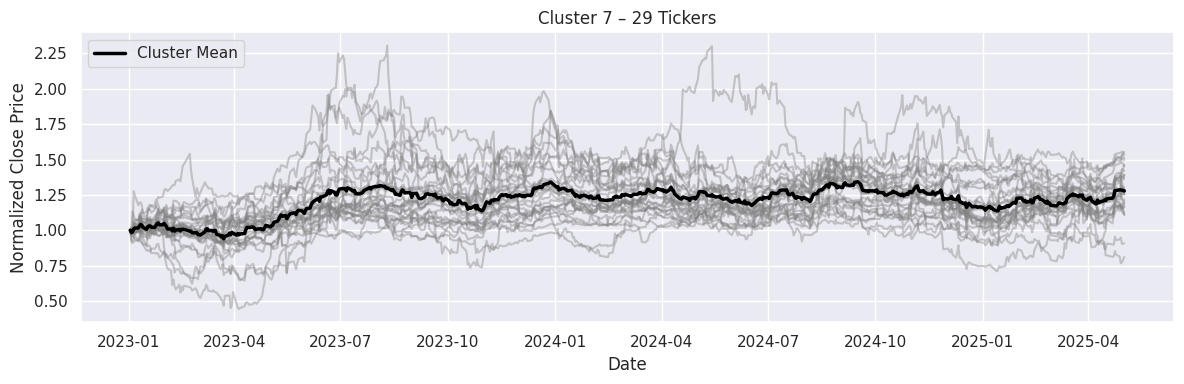

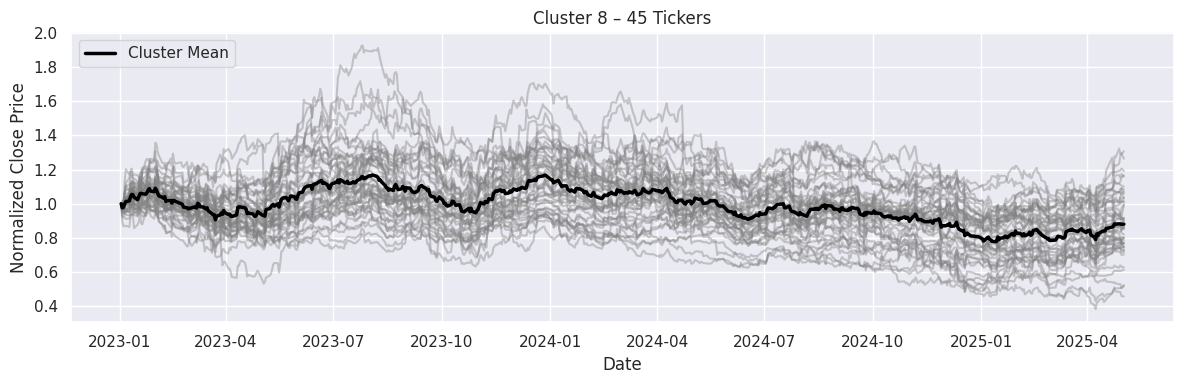

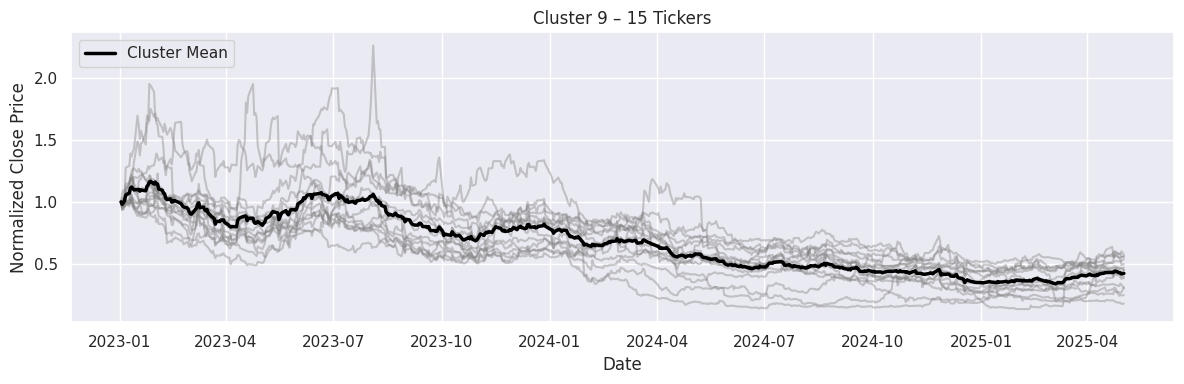

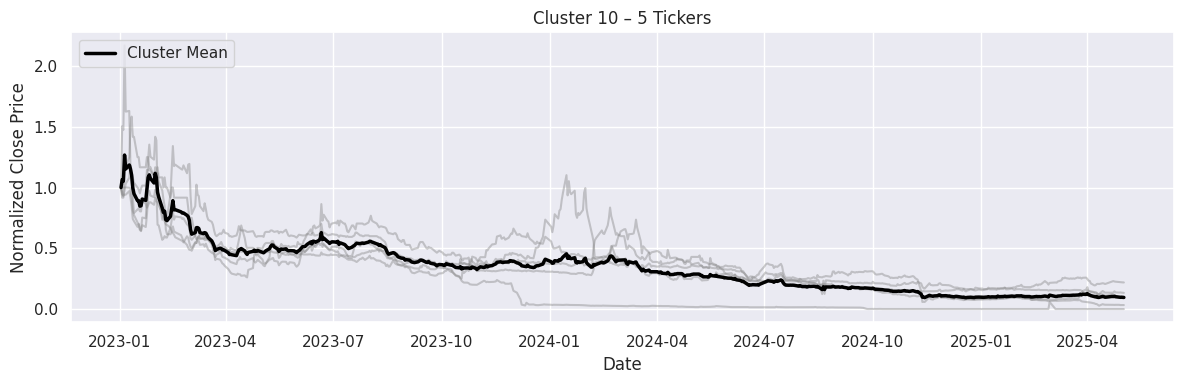

In [214]:
import matplotlib.pyplot as plt

# Normalization by dividing by the first value

# Plot time series for each cluster with mean series highlighted
for cluster_id in range(1, k + 1):
    plt.figure(figsize=(12, 4))
    cluster_tickers = [ticker for ticker, c in cluster_map.items() if c == cluster_id]

    # Extract and plot each ticker's time series (light gray)
    for ticker in cluster_tickers:
        plt.plot(pivot_norm.index, pivot_norm[ticker], color='gray', alpha=0.4)

    # Compute and plot the cluster mean series (bold)
    cluster_series = pivot_norm[cluster_tickers]
    cluster_mean = cluster_series.mean(axis=1)
    plt.plot(pivot_norm.index, cluster_mean, color='black', linewidth=2.5, label='Cluster Mean')

    plt.title(f"Cluster {cluster_id} – {len(cluster_tickers)} Tickers")
    plt.xlabel("Date")
    plt.ylabel("Normalized Close Price")
    plt.legend(loc='upper left')
    plt.tight_layout()
    plt.show()

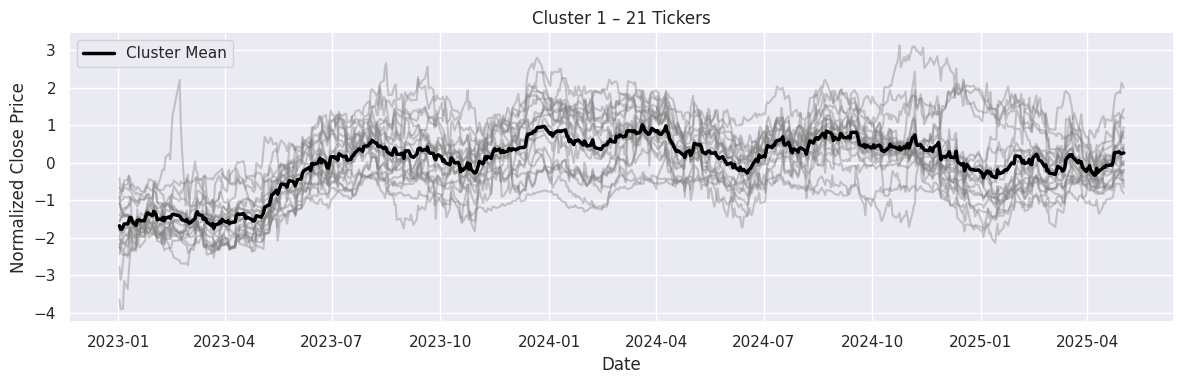

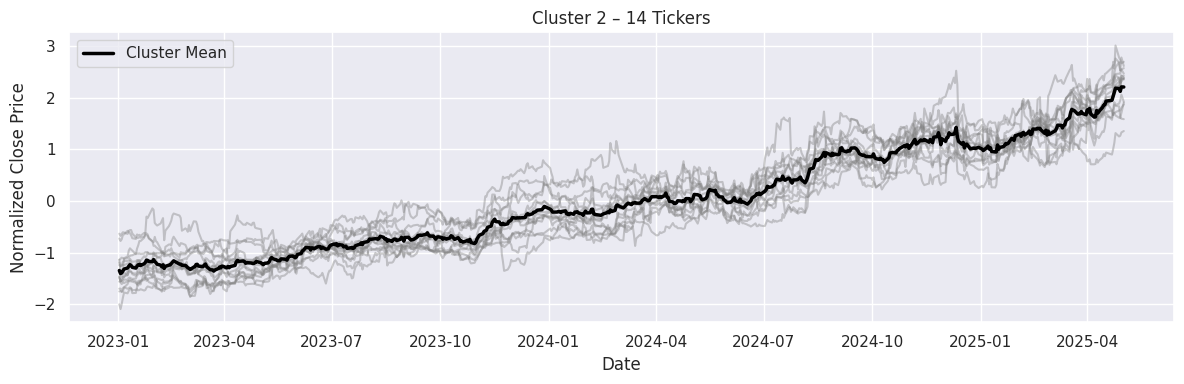

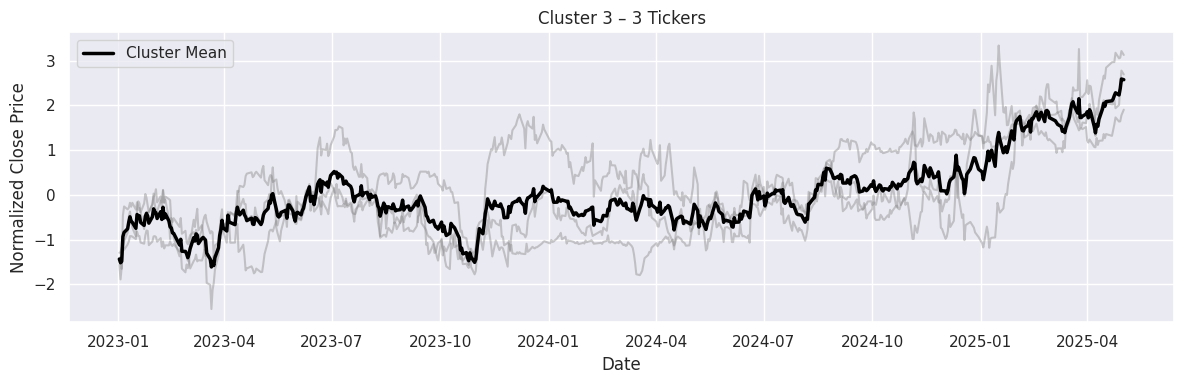

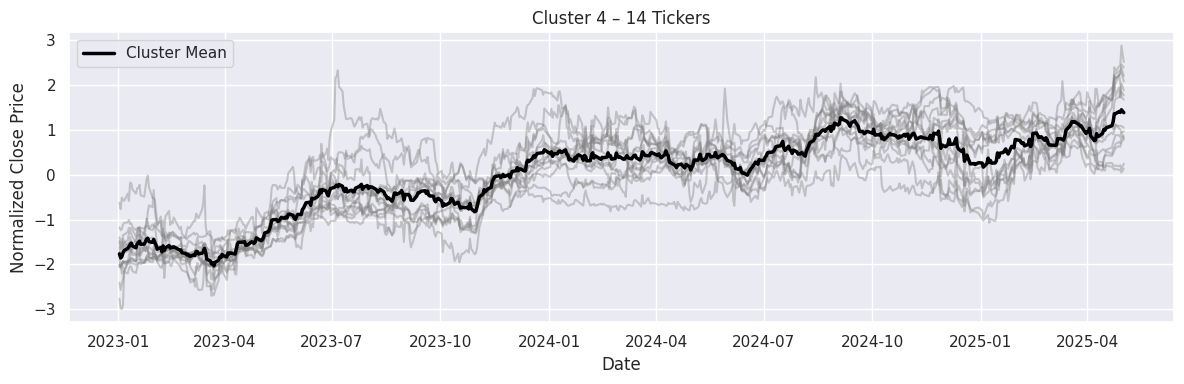

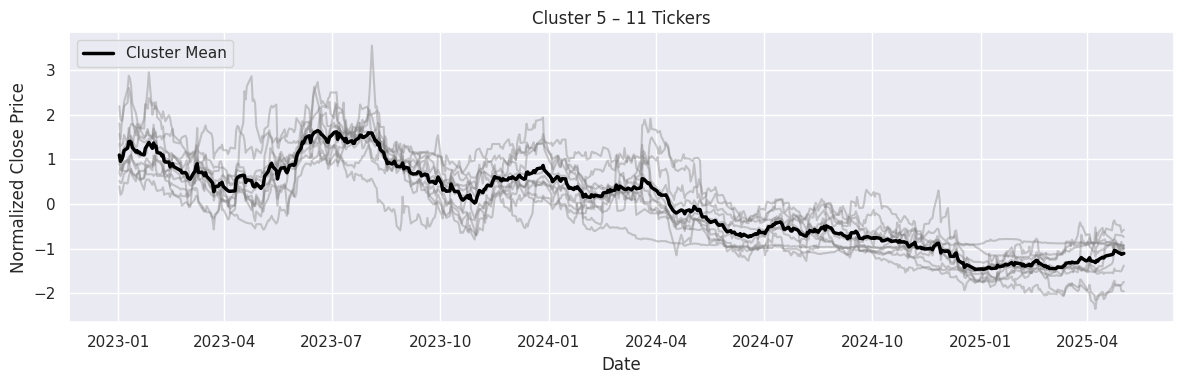

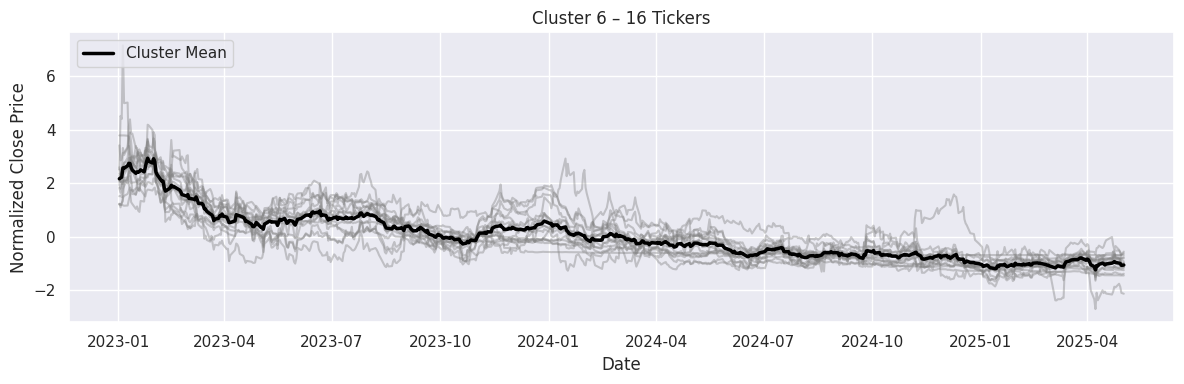

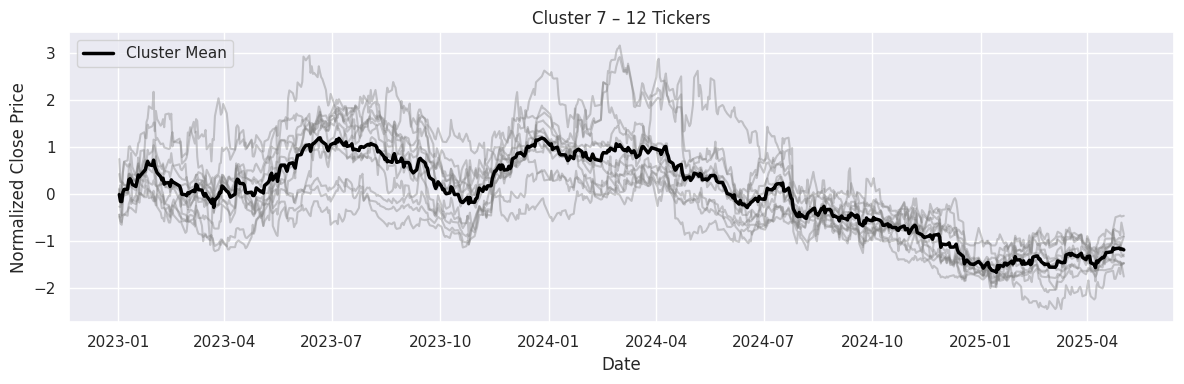

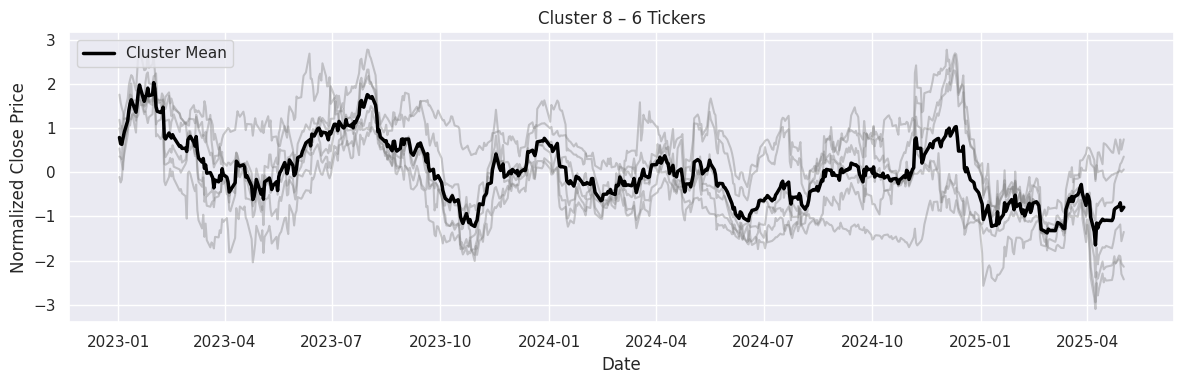

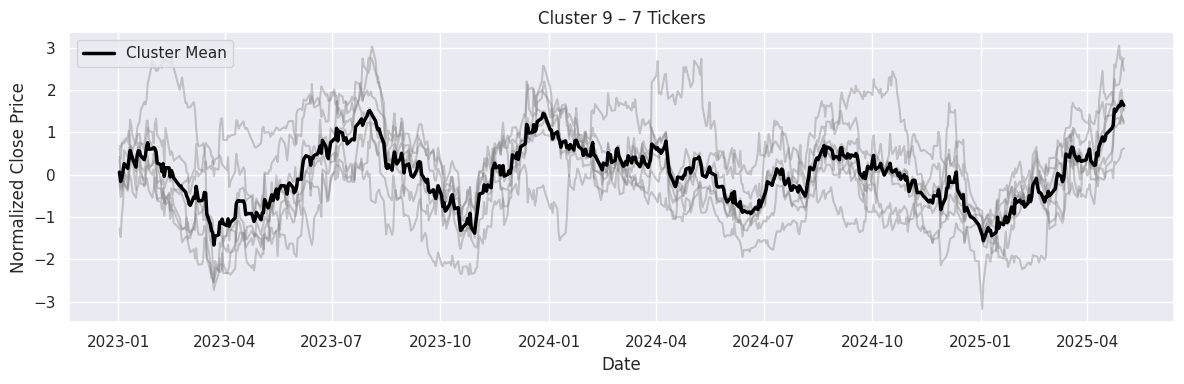

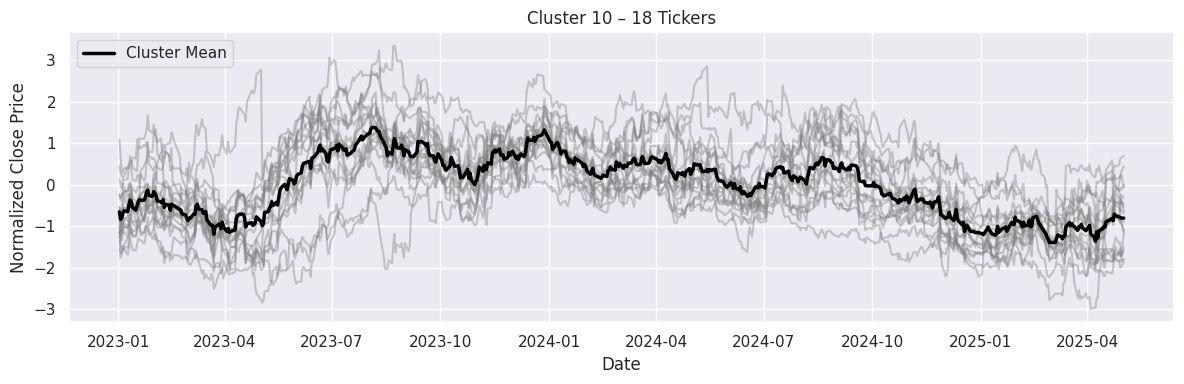

In [215]:
import matplotlib.pyplot as plt

# Normalization by dividing by the first value and standardizing

# Plot time series for each cluster with mean series highlighted
for cluster_id in range(1, k + 1):
    plt.figure(figsize=(12, 4))
    cluster_tickers = [ticker for ticker, c in cluster_map2.items() if c == cluster_id]

    # Extract and plot each ticker's time series (light gray)
    for ticker in cluster_tickers:
        plt.plot(pivot_norm2.index, pivot_norm2[ticker], color='gray', alpha=0.4)

    # Compute and plot the cluster mean series (bold)
    cluster_series = pivot_norm2[cluster_tickers]
    cluster_mean = cluster_series.mean(axis=1)
    plt.plot(pivot_norm2.index, cluster_mean, color='black', linewidth=2.5, label='Cluster Mean')

    plt.title(f"Cluster {cluster_id} – {len(cluster_tickers)} Tickers")
    plt.xlabel("Date")
    plt.ylabel("Normalized Close Price")
    plt.legend(loc='upper left')
    plt.tight_layout()
    plt.show()

### Selecting Ideal Clusters

In [216]:
clusterk = pivot_df.columns[(cluster_labels <= 6)].to_list()

In [217]:
clusterk2 = pivot_df.columns[(cluster_labels2 == 2) | (cluster_labels2 == 4)].to_list()

In [220]:
candidates = df_financials.loc[
    (df_financials['TICKER1'].isin(clusterk)) & (df_financials['DT_FIM_EXERC'].str[:4] == '2024')
][['TICKER1', 'CNPJ', 'NOME', 'DT_FIM_EXERC', 'RECEITA_LIQUIDA', 'LUCRO_CONSOLIDADO', 'PATRIMONIO_LIQUIDO']]

In [221]:
candidates2 = df_financials.loc[
    (df_financials['TICKER1'].isin(clusterk2)) & (df_financials['DT_FIM_EXERC'].str[:4] == '2024')
][['TICKER1', 'CNPJ', 'NOME', 'DT_FIM_EXERC', 'RECEITA_LIQUIDA', 'LUCRO_CONSOLIDADO', 'PATRIMONIO_LIQUIDO']]

In [223]:
candidates.merge(
    candidates2[['CNPJ']],
    how='inner',
    on='CNPJ'
)

,TICKER1,CNPJ,NOME,DT_FIM_EXERC,RECEITA_LIQUIDA,LUCRO_CONSOLIDADO,PATRIMONIO_LIQUIDO
0,BRFS3.SA,01.838.723/0001-27,BRF S.A.,2024-12-31,61379038.0,3691904.0,16499204.0
1,SBSP3.SA,43.776.517/0001-80,CIA SANEAMENTO BASICO EST SAO PAULO,2024-12-31,36145477.0,9579563.0,36928054.0
2,CSMG3.SA,17.281.106/0001-03,CIA SANEAMENTO DE MINAS GERAIS-COPASA MG,2024-12-31,7878006.0,1316920.0,8048229.0
3,CYRE3.SA,73.178.600/0001-18,CYRELA BRAZIL REALTY S.A.EMPREEND E PART,2024-12-31,7965688.0,1921052.0,9949274.0
4,DIRR3.SA,16.614.075/0001-00,DIRECIONAL ENGENHARIA S.A.,2024-12-31,3348470.0,727668.0,2223751.0
5,EMBR3.SA,07.689.002/0001-89,EMBRAER S.A.,2024-12-31,35424174.0,1923831.0,20710908.0
6,FRAS3.SA,88.610.126/0001-29,FRAS-LE S.A.,2024-12-31,3965776.0,374703.0,2251485.0
7,JBSS3.SA,02.916.265/0001-60,JBS S.A.,2024-12-31,416952002.0,10703994.0,50370426.0
8,POMO3.SA,88.611.835/0001-29,MARCOPOLO S.A.,2024-12-31,8593837.0,1222377.0,4082336.0
9,MRFG3.SA,03.853.896/0001-40,MARFRIG GLOBAL FOODS S.A.,2024-12-31,148860959.0,3880870.0,19938112.0


<Axes: xlabel='Date'>

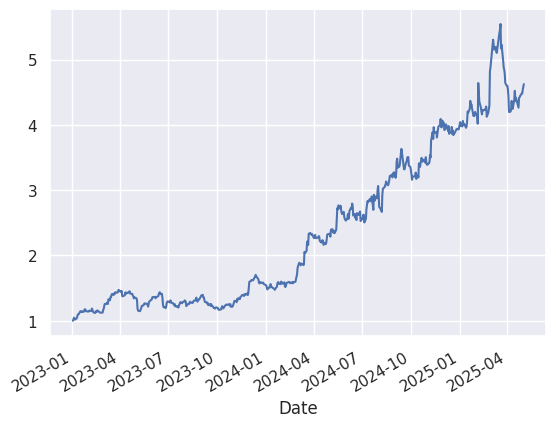

In [232]:
pivot_norm.loc[:, 'EMBR3.SA'].plot()